# SysSim — ARIA Tutorial (2026-06-04)

SysSim (https://github.com/AISysSim/SysSim) estimates the step time and peak memory of LLM training on hardware
you don't have, without running real computation. This notebook walks through six sections:

0. **Getting Started** — install → (profile) → calibrate → your first simulation (inspect the `SimulationReport`)
1. **SysSim vs. real GH200** — Qwen3-8B & Llama-3-8B, single- and multi-node, checked within 10%
2. **Sweeping** — Batch / Seqlen / TP / Precision sweeps
3. **New accelerator** — AMD MI300X (real)
4. **Accelerator integration** — custom estimator via `HardwareConfig(estimator=...)`

**Before you run anything:** _Runtime → Change runtime type → T4 GPU_.
(If the install cell fails on T4, fall back to L4 or A100.)

## SysSim Workflow

SysSim estimates LLM training performance by combining your specific configurations into a simulated environment. It treats performance as a deterministic outcome of these three primary inputs:

*   **Model Config:** Defines the neural network architecture. These parameters dictate the total number of floating-point operations (FLOPs) required per training step.

```yaml
# examples/configs/models/qwen3-1_7b.yaml
num_layers: 28
hidden_size: 2048
num_attention_heads: 16
num_query_groups: 8           # GQA
ffn_hidden_size: 6144
seq_length: 4096
```

*   **Hardware Config:** Defines the capabilities of your target device (TFLOPS, Memory Bandwidth, HBM). This allows SysSim to calculate the "speed limit" for every kernel and detect potential Out-of-Memory (OOM) errors.

```yaml
# examples/configs/hardware/isambard_gh200_4gpu.yaml
peak_tflops_mm: 1979           # tensor-unit peak (TFLOP/s)
peak_tflops_math: 989          # vector/math peak (TFLOP/s)
peak_memory_bandwidth_GBps: 3350
peak_tflops_mm_fp8: 3958

gpus_per_node: 4
gpu_memory_GB: 96              # per-GPU HBM; enables OOM detection

topology:
  dims:      [ fully_connected ]   # per dimension: fully_connected | switch | ring
  size:      [ 4 ]                 # endpoints in this dimension (4 NVLink-meshed GH200)
  bandwidth: [ 450 ]               # per-GPU uni-directional GB/s (900 NVLink bidir / 2)
  latency:   [ 12000 ]             # link latency (ns)
```

*   **Parallelism Config:** Defines the training strategy (TP, DP, PP size) and execution details (micro-batch size, precision, activation recomputation).

*   **Simulation Report:** The final output providing a multidimensional view of performance:
    *   **Step Time Breakdown:** Total wall-clock time partitioned into **Forward**, **Backward**, and **Optimizer** phases.
    *   **Communication Analysis:** Comparison of **Collective Total** vs. **Collective Exposed** (time not hidden by computation).
    *   **Efficiency (MFU/HFU):** Model and Hardware FLOPs utilization indicating how well the strategy saturates the silicon.
    *   **Memory Footprint:** Detailed breakdown of **Peak Memory (GB)** into Parameters, Gradients, Optimizer State, and Activations across pipeline stages.

```text
+----------------+       +------------------+       +--------------------+
|  Model Config  |       |  Hardware Config |       | Parallelism Config |
| (Architecture) |       | (Device Specs)   |       | (Training Strategy)|
+-------+--------+       +--------+---------+       +---------+----------+
        |                         |                           |
        +------------+            |             +-------------+
                     |            |             |
                     v            v             v
      +-----------------------------------------------------------+
      |                      SysSim Engine                        |
      |      Processes inputs to simulate execution timing       |
      +-----------------------------+-----------------------------+
                                    |
                                    v
      +-----------------------------------------------------------+
      |                     Simulation Report                     |
      | (Step Time, Phase Splits, Memory Breakdown, Efficiency)   |
      +-----------------------------------------------------------+
```

### 📖 Terminology & Core Metrics

To better understand the SysSim reports and configurations, here are key concepts and metrics defined:

*   **TP (Tensor Parallelism):** Shards individual weight matrices and activations across multiple GPUs. It reduces memory per device but adds communication overhead on the 'critical path' of every layer.
*   **DP (Data Parallelism):** Distributes the training data across GPUs. Each GPU holds a full copy of the model (or shards it via ZeRO/Distributed Optimizer) and processes different data samples.
*   **MFU (Model FLOPs Utilization):** The ratio of the throughput (floating-point operations per second) achieved compared to the theoretical peak performance of the hardware when executing only the model's math.
*   **HFU (Hardware FLOPs Utilization):** A broader metric that includes overheads like activation recomputation. It measures how effectively the entire hardware's compute capacity is being used.
*   **Roofline Floor:** A theoretical 'speed limit' calculation based on hardware peaks (TFLOPS and Bandwidth). It assumes the hardware is perfectly efficient.
*   **Operator Profile:** A collection of real-world measurements of how long specific mathematical operations (like matrix multiplications) take on the actual target hardware.
*   **Calibration & Residuals:** The process of adjusting the 'Roofline' model to match real-world data. The **Residual** is the gap between predicted and actual time; SysSim uses LightGBM to learn this gap to improve accuracy.

In [ ]:
import torch
assert torch.cuda.is_available(), (
    "SysSim requires a GPU runtime. "
    "Runtime → Change runtime type → T4 GPU (or L4/A100), then re-run."
)
print(f"GPU: {torch.cuda.get_device_name(0)}")

GPU: Tesla T4


## §0. Getting Started

The recommended path for a first run of SysSim: **install → (profile) → calibrate → simulate**. By the end you'll have the GH200-calibrated cost model set up and will have run your first simulation, inspecting the full `SimulationReport`.

### Step 1 — Installation

Clone SysSim (with submodules) and install it into the Colab runtime. This is the only step here that performs a heavy install; it takes ~3–5 minutes on a fresh runtime.

In [ ]:
import os, subprocess
import logging, warnings
import shutil # Import shutil for directory removal

# Silence benign Megatron / Apex / RNG warnings so the demo output stays readable.
logging.getLogger("megatron.core.tensor_parallel.random").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", message="CPU RNG state changed within GPU RNG context")
warnings.filterwarnings("ignore", message="Module is None. Skipping .* hook.")
warnings.filterwarnings("ignore", message="Apex is not installed.*")
warnings.filterwarnings("ignore", message="full scope is deprecated.*")

# 1) Clone SysSim (mksit/aria_tutorial branch, with submodules) into the Colab runtime.
#    Ensure a clean state by removing the directory if it exists.
if os.path.exists("SysSim"):
    print("SysSim directory already exists. Attempting to remove with rm -rf to ensure clean clone.")
    subprocess.run("rm -rf SysSim", shell=True, check=True)

# Clone the repository. Git will create the 'SysSim' directory.
print("Cloning SysSim (mksit/aria_tutorial branch)...")
subprocess.run(
    "git clone --branch mksit/aria_tutorial https://github.com/AISysSim/SysSim.git",
    shell=True, check=True,
)

# Change into the SysSim directory for submodule updates
if os.path.basename(os.getcwd()) != "SysSim":
    %cd SysSim

# Configure git to use https for git:// protocol, which can help with submodule cloning issues
print("Configuring git to use HTTPS for git:// and SSH (git@) URLs (the PLENA submodule uses SSH)...")
subprocess.run(
    "git config --global url.\"https://\".insteadOf git://",
    shell=True, check=True
)
subprocess.run(
    "git config --global url.\"https://github.com/\".insteadOf \"git@github.com:\"",
    shell=True, check=True
)

print("Initializing and updating submodules...")
subprocess.run(
    "git submodule update --init --recursive",
    shell=True # Removed check=True to allow script to continue on non-fatal errors
)

# 2) Make the editable install work on Colab.
#    The repo root holds several top-level dirs (data/, syssim/, third_party/),
#    so setuptools' flat-layout auto-discovery refuses to guess. Scope it to the
#    syssim package explicitly. (Runtime-only tweak; the repo is unchanged upstream.)
_pp = "pyproject.toml"
_txt = open(_pp).read()
if "tool.setuptools.packages.find" not in _txt:
    with open(_pp, "a") as _f:
        _f.write('\n[tool.setuptools.packages.find]\ninclude = ["syssim*"]\n')

# 3) Install the SysSim deps that aren't already on a Colab runtime.
#    lightgbm (and everything else: numpy, pandas, pyarrow, pyyaml, scikit-learn,
#    torch, transformers) -- the rest already ship with Colab.
!pip install -q lightgbm 2>&1 | tail -3

#    megatron-core is pinned to 0.13.1 (the GH200-validated version): peak memory is read
#    from the fake-tensor trace and is sensitive to the megatron-core version (newer versions
#    allocate optimizer state lazily and the trace under-counts). It is installed with
#    --no-deps on purpose: 0.13.1's metadata caps numpy<2, but Colab ships numpy 2.x with
#    pandas built against it, so a normal install would downgrade numpy and break pandas'
#    compiled C-ABI ("numpy.dtype size changed"). 0.13.1 runs fine under numpy 2.x and its
#    only runtime dep (torch) is already on Colab, so --no-deps is safe.
!pip install -q --no-deps "megatron-core==0.13.1" 2>&1 | tail -3

# 4) Install SysSim itself (editable, no dep re-resolution).
!pip install -q --no-deps -e . 2>&1 | tail -3

import syssim
print(f"SysSim {syssim.__version__ if hasattr(syssim,'__version__') else ''} imported from: {syssim.__file__}")

Cloning SysSim (mksit/aria_tutorial branch)...
Configuring git to use HTTPS for git:// and SSH (git@) URLs (the PLENA submodule uses SSH)...
Initializing and updating submodules...
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
SysSim  imported from: /content/SysSim/syssim/__init__.py


### Step 2 — Profiling (shown, not run here)

Profiling measures the **real GPU self-time** of every operator a Megatron transformer layer dispatches, across SysSim's architecture/shape space, and writes them to `data/<device>/profile.parquet`. These measurements are what calibrates the per-operator cost model.

Profiling needs the **actual target GPUs** (real kernels on the real device), so it is **not run in this notebook** — Colab's T4 is not a GH200. The real command on a 4-GPU GH200 node is:

```bash
python -m syssim profile --out data/gh200 --num-workers 4
```

In [ ]:
# DRY RUN ONLY — previews the profiling job list (layer configs x tensor-parallel
# shapes). It does NOT profile and does NOT touch the GPU. Real profiling needs the
# target GH200 GPUs; we ship data/gh200/profile.parquet so you can skip it.
!python -m syssim profile --out data/gh200 --dry-run

dry run: 158 layer-config jobs (42 configs x tensor-parallel [1, 2, 4, 8], divisible only); seq points [128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768]


### Step 3 — Calibration

Calibration fits the per-operator cost model from the shipped profile. For each operator family (GEMM, elementwise, reduction) it learns a small LightGBM **residual** — `log(measured_time / roofline_anchor)` as a function of op size — on top of the roofline floor. This is **CPU-only**, so it runs fine here on Colab.

It reads `data/gh200/profile.parquet` and writes the per-family models (`gemm_model.lgb`, `elementwise_model.lgb`, `reduction_model.lgb`) plus `manifest.json` into `data/gh200/`.

In [ ]:
# Fit the per-family residual trees from the shipped GH200 profile (CPU-only).
# Writes gemm/elementwise/reduction *.lgb + manifest.json into data/gh200/.
!python -m syssim calibrate --data data/gh200 --hardware examples/configs/hardware/isambard_gh200_4gpu.yaml

calibrate: loaded 23016 (op, shape) rows from data/gh200/profile.parquet
calibrate: built feature codes (22 op subtypes); families = gemm, elementwise, reduction
calibrate: fitting gemm ...
calibrate: gemm done -> median_ape=6.2%  p95=64.3%  (train=4573 val=1265)
calibrate: fitting elementwise ...
calibrate: elementwise done -> median_ape=6.0%  p95=44.6%  (train=10856 val=2045)
calibrate: fitting reduction ...
calibrate: reduction done -> median_ape=4.6%  p95=19.3%  (train=3831 val=446)
calibrated 3 families -> data/gh200 (gemm_model.lgb, elementwise_model.lgb, reduction_model.lgb + manifest.json)


### Step 4 — Your first simulation

Run one configuration end-to-end to generate a `SimulationReport`. This report is the source of truth for your model's projected performance on the target hardware.

#### Simulation Report
`syssim.simulate(...)` returns a **SimulationReport** containing:

| Field | Meaning |
| :--- | :--- |
| **step_time_ms** | Estimated wall-clock step time |
| **forward_ms / backward_ms / optimizer_ms** | Time attributed per training phase |
| **collective_total_ms / collective_exposed_ms** | Total vs. non-overlapped collective time |
| **achieved_tflops, mfu, hfu** | Throughput and model/hardware FLOPs utilization |
| **peak_memory_gb** | Peak per-GPU memory (heaviest pipeline stage) |
| **pp_stage_memory_gb** | Per-pipeline-stage peak memory (one entry per stage) |
| **per_pp_rank_step_time_ms** | Per-stage finish time |
| **bottlenecks** | Top ops, dominant op type, longest collective, binding PP stage, peak module, and OOM data |

**Note on Memory:** `peak_memory_gb` represents the heaviest pipeline stage. The report further breaks this down into parameters, gradients, optimizer state, and activations.

Below, we simulate **Qwen3-8B** with Tensor Parallelism (**TP=2**) on the GH200-calibrated cost model we just built.

In [ ]:
import syssim

report = syssim.simulate(
    model="examples/configs/models/qwen3-8b.yaml",
    hardware="examples/configs/hardware/isambard_gh200_4gpu.yaml",
    parallelism=syssim.ParallelismConfig(tp=2, dp=1),
    training=syssim.TrainingConfig(micro_batch=1, global_batch=1, dtype="bf16", recompute="full"),
)
print(report)

SimulationReport(
  step_time_ms        = 644.6507
    forward_ms        = 184.5179
    backward_ms       = 383.1765
    optimizer_ms      = 39.4327
  collective_total_ms = 53.9978
  collective_exposed  = 37.5235
  achieved_tflops     = 184.55
  mfu                 = 9.33%
  hfu                 = 12.43%
  peak_memory_gb      = 26.133
  Bottlenecks(
    dominant_op_type = math
    top_ops_by_time  = [('optimizer_step_4289', 39.43271286447761), ('op_1181_aten.mm', 4.286653309549106), ('op_1182_aten.mm', 4.21173467212024)]
    peak_module      = Float16Module
  )
)


## §1. SysSim vs. real GH200 (Qwen3-8B & Llama-3-8B)

Now check SysSim against **real Megatron-core measurements** on GH200. The measured numbers come from `docs/megatron_gh200_validation/` (the published reference runs), and the hardware YAMLs carry `calibrated_model: data/gh200` so `simulate(...)` uses the GH200-calibrated cost model from §0.

Across the full validation suite — 16 single-node + 8 multi-node (2- and 4-node) cases — SysSim lands **within 10% on 24/24** (mean step-time error ~4%). The two sub-sections below show the **single-node** and **multi-node** slices.

#### Single-node — one 4-GPU GH200

`tp2` (TP=2) and `dp4` (DP=4) on a single node, bf16, full recompute. `dp4` uses Megatron's distributed optimizer (ZeRO-1) to shard optimizer state across the 4 data-parallel ranks.

     model case  sim_ms  real_ms  step_err_%  sim_gb  real_gb  mem_err_%
  Qwen3-8B  tp2   638.5    694.8         8.1    39.6     64.6       38.8
  Qwen3-8B  dp4  1165.9   1157.3         0.7    56.1     65.8       14.7
Llama-3-8B  tp2  1785.7   1842.4         3.1    44.6     69.4       35.7
Llama-3-8B  dp4  3252.4   3360.2         3.2    67.7     79.9       15.3

Max step-time error: 8.1%  |  Max memory error: 38.8%  (target: within 10%)


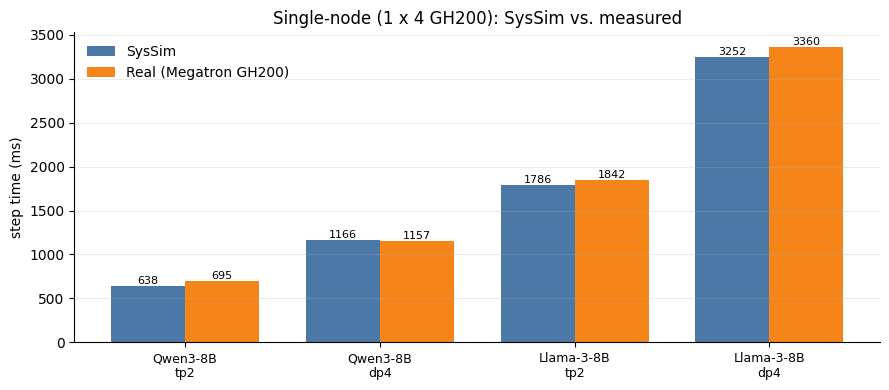

In [ ]:
import syssim
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

HW_1NODE = "examples/configs/hardware/isambard_gh200_4gpu.yaml"   # 1 node, 4 GPUs (calibrated_model: data/gh200)
HW_4NODE = "examples/configs/hardware/isambard_gh200_4node.yaml"  # 4 nodes, 16 GPUs (+ inter-node Slingshot)
MODELS = {
    "Qwen3-8B": "examples/configs/models/qwen3-8b.yaml",
    "Llama-3-8B": "examples/megatron/llama3-8b.yaml",
}

def headline_compare(cases, title):
    """Run each case through SysSim, tabulate vs. measured GH200, and bar-chart step time."""
    rows = []
    for model_name in MODELS:
        for case, cfg in cases[model_name].items():
            r = syssim.simulate(
                model=MODELS[model_name], hardware=cfg["hw"],
                parallelism=syssim.ParallelismConfig(tp=cfg["tp"], dp=cfg["dp"]),
                training=syssim.TrainingConfig(
                    micro_batch=cfg["micro_batch"], global_batch=cfg["global_batch"],
                    dtype="bf16", recompute="full",
                    use_distributed_optimizer=cfg["distopt"]),
            )
            rows.append({
                "model": model_name, "case": case,
                "sim_ms": round(r.step_time_ms, 1), "real_ms": cfg["real_ms"],
                "step_err_%": round(100 * abs(r.step_time_ms - cfg["real_ms"]) / cfg["real_ms"], 1),
                "sim_gb": round(r.peak_memory_gb, 1), "real_gb": round(cfg["real_gb"], 1),
                "mem_err_%": round(100 * abs(r.peak_memory_gb - cfg["real_gb"]) / cfg["real_gb"], 1),
            })
    df = pd.DataFrame(rows)
    print(df.to_string(index=False))
    print(f"\nMax step-time error: {df['step_err_%'].max():.1f}%  |  "
          f"Max memory error: {df['mem_err_%'].max():.1f}%  (target: within 10%)")

    labels = [f"{m}\n{c}" for m, c in zip(df["model"], df["case"])]
    x = range(len(df)); w = 0.38
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar([i - w/2 for i in x], df["sim_ms"], width=w, label="SysSim", color="#4C78A8")
    ax.bar([i + w/2 for i in x], df["real_ms"], width=w, label="Real (Megatron GH200)", color="#F58518")
    ax.set_xticks(list(x)); ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel("step time (ms)"); ax.set_title(title)
    ax.grid(axis="y", alpha=0.25); ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False)
    for i, (s, rl) in enumerate(zip(df["sim_ms"], df["real_ms"])):
        ax.text(i - w/2, s, f"{s:.0f}", ha="center", va="bottom", fontsize=8)
        ax.text(i + w/2, rl, f"{rl:.0f}", ha="center", va="bottom", fontsize=8)
    plt.tight_layout(); plt.show()
    return df

# Single-node: one 4-GPU GH200.
SINGLE_NODE = {
    "Qwen3-8B": {
        "tp2": dict(hw=HW_1NODE, tp=2, dp=1, micro_batch=1, global_batch=1, distopt=False, real_ms=694.8,  real_gb=64.63),
        "dp4": dict(hw=HW_1NODE, tp=1, dp=4, micro_batch=1, global_batch=4, distopt=True,  real_ms=1157.3, real_gb=65.84),
    },
    "Llama-3-8B": {
        "tp2": dict(hw=HW_1NODE, tp=2, dp=1, micro_batch=1, global_batch=1, distopt=False, real_ms=1842.4, real_gb=69.41),
        "dp4": dict(hw=HW_1NODE, tp=1, dp=4, micro_batch=1, global_batch=4, distopt=True,  real_ms=3360.2, real_gb=79.93),
    },
}
cmp_single = headline_compare(SINGLE_NODE, "Single-node (1 x 4 GH200): SysSim vs. measured")

**Takeaway:** Across both Qwen3-8B and Llama-3-8B, SysSim's predicted single-node step times sit right alongside the measured GH200 bars (≤8% error), so you can rely on these simulations to size single-node runs before booking real hardware.

#### Multi-node — 4 nodes × 4 GPUs (16 GPUs)

`tp4dp4` (TP=4 × DP=4) fanned across 4 GH200 nodes. SysSim simulates the inter-node Slingshot fabric, so this runs on the **same single Colab GPU** — no real multi-node job is required. (Reuses `headline_compare` from the single-node cell.)

     model         case  sim_ms  real_ms  step_err_%  sim_gb  real_gb  mem_err_%
  Qwen3-8B 4node tp4dp4   495.0    472.1         4.9    14.4     18.7       22.7
Llama-3-8B 4node tp4dp4  1148.2   1053.6         9.0    17.5     22.1       21.1

Max step-time error: 9.0%  |  Max memory error: 22.7%  (target: within 10%)


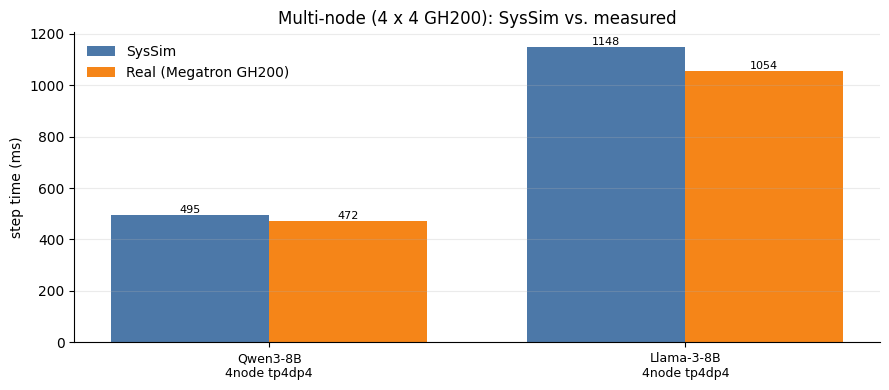

In [ ]:
# Multi-node: 4 nodes x 4 GPUs = 16 GPUs (TP=4 x DP=4). SysSim models the inter-node
# Slingshot fabric, so this still runs on the single Colab GPU -- no real cluster needed.
MULTI_NODE = {
    "Qwen3-8B": {
        "4node tp4dp4": dict(hw=HW_4NODE, tp=4, dp=4, micro_batch=1, global_batch=4, distopt=True, real_ms=472.1,  real_gb=18.69),
    },
    "Llama-3-8B": {
        "4node tp4dp4": dict(hw=HW_4NODE, tp=4, dp=4, micro_batch=1, global_batch=4, distopt=True, real_ms=1053.6, real_gb=22.15),
    },
}
cmp_multi = headline_compare(MULTI_NODE, "Multi-node (4 x 4 GH200): SysSim vs. measured")

**Takeaway:** SysSim keeps the same close agreement once you scale out to 16 GPUs across 4 nodes — modeling the inter-node Slingshot fabric in software — so you can confidently project multi-node performance without ever standing up a real cluster.

## §2. Sweeping — Batch / Seqlen / TP / Precision

With the cost model calibrated, explore the configuration space *without touching a GPU* — change one
knob and read off the predicted effect. SysSim's `sweep(...)` helper re-runs `simulate()` across a
config axis and returns a tidy table (`.to_dataframe()`, plus `.best(metric)`).

Model = **Qwen3-1.7B**, hardware = **GH200 (one node, 4 GPUs)**. We sweep one knob at a time —
micro-batch, sequence length, tensor-parallel (TP) size and precision (bf16/fp8) — each with its own table and trend plot.
The dashed line in the memory panel marks the 96 GB per-GPU limit, so you can see where a config
would OOM.

In [ ]:
import syssim
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

QWEN3 = "examples/configs/models/qwen3-1_7b.yaml"              # small model -> fast sweeps
HW    = "examples/configs/hardware/isambard_gh200_4gpu.yaml"   # GH200, one node (4 GPUs)
GPU_MEM_GB = 96                                                # per-GPU HBM (OOM line)

def plot_sweep(sw, axis, title):
    """Print a Sweep as a table and plot step time / memory / MFU vs the swept axis."""
    df = sw.to_dataframe() if hasattr(sw, "to_dataframe") else sw
    print(df.to_string(index=False))
    x = [str(v) for v in df[axis]]
    fig, axes = plt.subplots(1, 3, figsize=(12, 3))
    for ax, (metric, lbl) in zip(axes, [("step_time_ms", "step time (ms)"),
                                        ("peak_memory_gb", "peak memory (GB)"),
                                        ("mfu", "MFU")]):
        ax.plot(x, df[metric], marker="o", linewidth=2, color="#4C78A8")
        ax.set_xlabel(axis.split(".")[-1]); ax.set_title(lbl); ax.grid(alpha=0.25)
        if metric == "peak_memory_gb":
            ax.axhline(GPU_MEM_GB, color="#E45756", ls="--", lw=1, label=f"{GPU_MEM_GB} GB")
            ax.legend(fontsize=7, frameon=False)
    fig.suptitle(title, y=1.03); fig.tight_layout(); plt.show()

### Micro-batch size

Bigger micro-batches pack more tokens per step (higher MFU) but cost more activation memory. Sweep
`training.micro_batch` ∈ {1, 2, 4, 8, 16} at TP=2, DP=2 — the large values blow past the 96 GB limit,
which SysSim flags as OOM *before* you ever launch.

 training.micro_batch  step_time_ms      mfu  peak_memory_gb
                    1   2470.017755 0.046408       33.716554
                    2   2384.697103 0.048069       61.250919
                    4   2355.162859 0.048672      116.319648
                    8   2288.321477 0.050093      226.457107
                   16   2246.251269 0.051031      446.732024


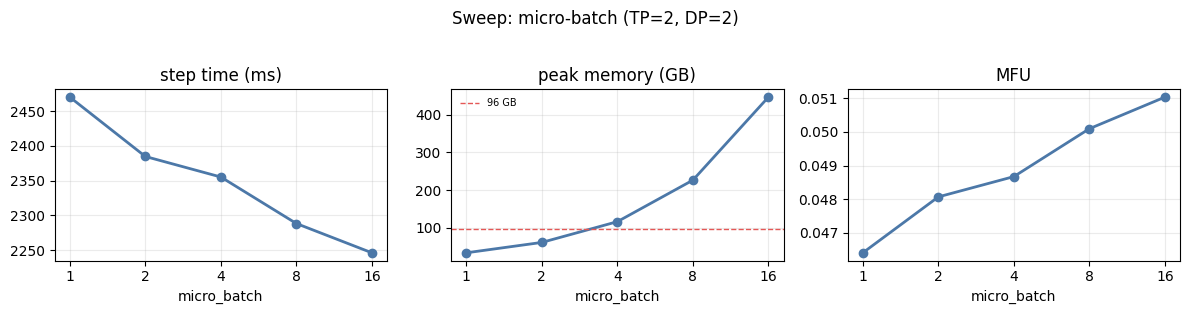

In [ ]:
plot_sweep(
    syssim.sweep(model=QWEN3, hardware=HW,
        parallelism=syssim.ParallelismConfig(tp=2, dp=2),
        training=syssim.TrainingConfig(micro_batch=1, global_batch=32, dtype="bf16"),
        over={"training.micro_batch": [1, 2, 4, 8, 16]}),
    "training.micro_batch", "Sweep: micro-batch (TP=2, DP=2)")

**Takeaway:** Larger micro-batches steadily lift MFU and trim step time, but activation memory climbs fast — and SysSim flags exactly which micro-batch values cross the 96 GB line (OOM) so you can pick the largest safe batch up front.

### Sequence length

Attention cost grows ~quadratically in sequence length, so step time and activation memory both climb.
`seq_length` lives in the model YAML, so we sweep the `model.seq_length` axis ∈ {2048, 4096, 8192} at
TP=2, DP=2.

 model.seq_length  step_time_ms      mfu  peak_memory_gb
             2048    245.519152 0.052421       14.832305
             4096    632.665165 0.045296       33.716554
             8192   1995.318971 0.034572      100.778073


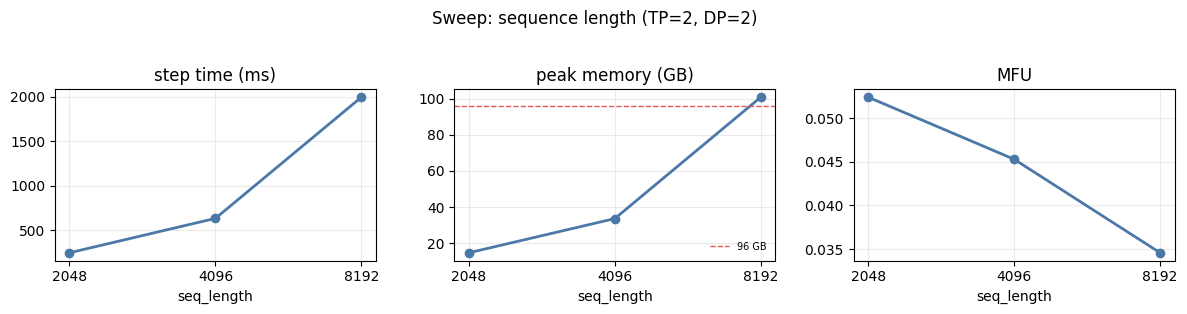

In [ ]:
plot_sweep(
    syssim.sweep(model=QWEN3, hardware=HW,
        parallelism=syssim.ParallelismConfig(tp=2, dp=2),
        training=syssim.TrainingConfig(micro_batch=1, global_batch=8, dtype="bf16"),
        over={"model.seq_length": [2048, 4096, 8192]}),
    "model.seq_length", "Sweep: sequence length (TP=2, DP=2)")

**Takeaway:** Doubling sequence length roughly quadruples attention cost, so step time and activation memory both rise sharply — use this curve to anticipate where longer contexts push you toward the memory ceiling and budget compute accordingly.

### Tensor-parallel (TP) size

TP shards each layer's weights and activations across GPUs: less memory per GPU, more all-reduce traffic
on the critical path. Sweep `parallelism.tp` ∈ {1, 2, 4} at DP=1 (Qwen3-1.7B has 8 KV groups, so TP
beyond that buys little — we keep it ≤4).

 parallelism.tp  step_time_ms      mfu  peak_memory_gb
              1    279.652662 0.102475       63.897000
              2    159.757355 0.089690       33.716554
              4    107.032796 0.066936       18.626329


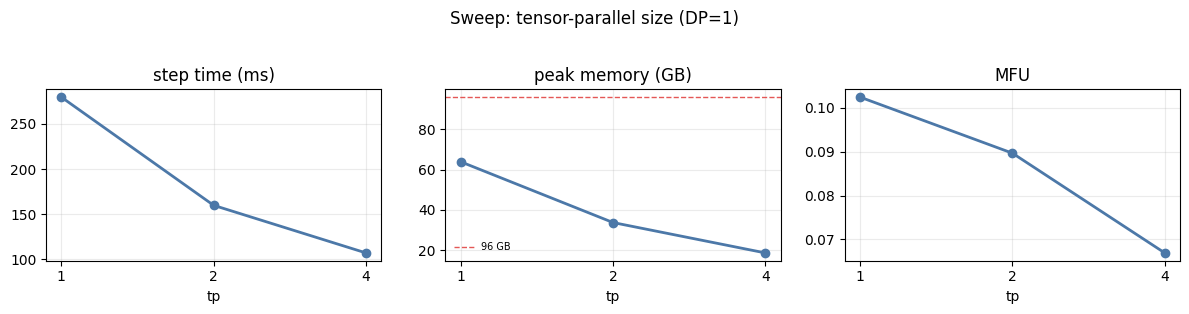

In [ ]:
plot_sweep(
    syssim.sweep(model=QWEN3, hardware=HW,
        parallelism=syssim.ParallelismConfig(dp=1),
        training=syssim.TrainingConfig(micro_batch=1, global_batch=1, dtype="bf16"),
        over={"parallelism.tp": [1, 2, 4]}),
    "parallelism.tp", "Sweep: tensor-parallel size (DP=1)")

**Takeaway:** Raising TP shards weights across more GPUs, cutting per-GPU memory and step time, while MFU eases off as all-reduce traffic grows — the sweet spot here is bounded by the model's 8 KV groups, so TP≤4 captures the gains.

### Precision (bf16 vs fp8)

Lower precision raises the matrix-engine peak (GH200: bf16 1979 → fp8 3958 TFLOP/s). Sweep
`training.dtype` ∈ {bf16, fp8} at TP=2, DP=2.

> **fp8 figures are illustrative.** fp8's payoff is shape- and kernel-dependent — cast/scale overhead
> and small GEMMs can erase the peak advantage, and fp8 training carries extra buffers (more memory).
> For a model this small fp8 is *not* a clear win here; read the exact fp8 numbers with care.

training.dtype  step_time_ms      mfu  peak_memory_gb
          bf16    632.665165 0.045296       33.716554
           fp8   1039.356255 0.027572       55.295077


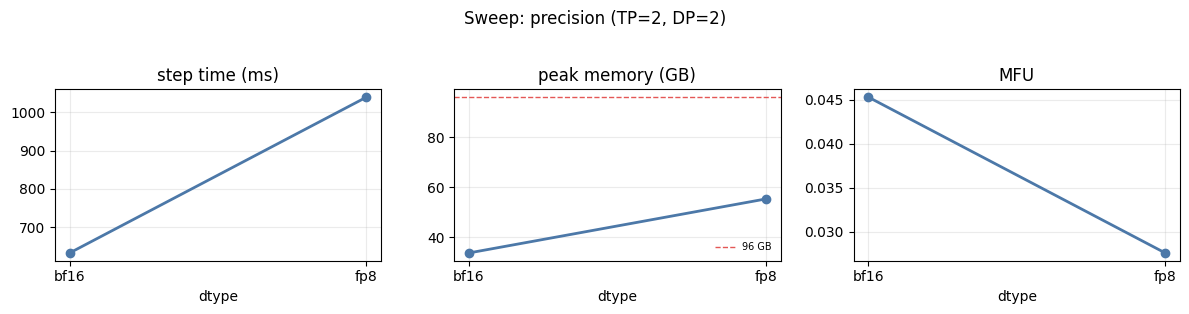

In [ ]:
plot_sweep(
    syssim.sweep(model=QWEN3, hardware=HW,
        parallelism=syssim.ParallelismConfig(tp=2, dp=2),
        training=syssim.TrainingConfig(micro_batch=1, global_batch=8, dtype="bf16"),
        over={"training.dtype": ["bf16", "fp8"]}),
    "training.dtype", "Sweep: precision (TP=2, DP=2)")

**Takeaway:** This sweep shows how to compare precisions side by side: fp8 roughly doubles the matrix-engine peak, and SysSim lets you weigh that against fp8's extra buffers and cast overhead — for a model this small the bf16/fp8 trade-off is close, so treat the fp8 figures as illustrative.

## Advanced Usages

## §3. New accelerator — AMD MI300X (real)

SysSim isn't GH200-specific: any accelerator plugs in through a hardware YAML and the same
**profile → calibrate → simulate** flow from §1. Here we bring up **AMD MI300X** for real.

This section was run end-to-end on a **RunPod single-GPU MI300X** (gfx942, SR-IOV) under ROCm
(`torch 2.5.1+rocm6.2`). The device is described by
`examples/configs/hardware/runpod_mi300x_1gpu.yaml` — AMD spec-sheet peaks (which serve as the
roofline / calibration anchor) **plus a `calibrated_model:` fit from on-device profiling**, so
SysSim uses the *measured* per-operator cost model rather than the bare roofline floor. The numbers
below are a **real accuracy check** against a measured Megatron training step.

#### 1. Profile (run on the real MI300X)

Profiling measures the **real GPU self-time** of every operator a Megatron transformer layer
dispatches and writes `data/mi300x/profile.parquet`. It needs the actual device, so it was run on
the RunPod MI300X (single GPU → `--num-workers 1`):

```bash
python -m syssim profile --out data/mi300x --num-workers 1
```

This profiled **158 layer-config jobs** (42 architectures × TP shards [1,2,4,8]) → **23,842 unique
`(op, shape)` rows** in ~100 min. Every recorded time is GPU device-time (read from `roctracer` via
`torch.profiler`); CPU-only ops get `t≤0` and are dropped, so the parquet is GPU-only by
construction.

#### 2. Calibrate (fit from the real profile)

Calibration fits the per-operator residual model from `data/mi300x/profile.parquet` (CPU-only):

```bash
python -m syssim calibrate --data data/mi300x --hardware examples/configs/hardware/runpod_mi300x_1gpu.yaml
```

This learned three per-family LightGBM residual trees on the 23,842 rows — held-out fit:
**gemm median APE 7.0%, elementwise 8.1%, reduction 6.3%** — and wrote `gemm_model.lgb`,
`elementwise_model.lgb`, `reduction_model.lgb` + `manifest.json` into `data/mi300x/`. The hardware
YAML then carries **`calibrated_model: data/mi300x`**, so `simulate(...)` predicts
`roofline(peaks) × exp(residual)` instead of the bare roofline floor.

#### 3. Simulate one case and compare to the real run

With the calibrated hardware YAML in hand, `simulate()` runs on any machine — no MI300X required.
We simulate a single config (**Qwen3-1.7B, one GPU, bf16**) and line it up against the **real
measured** Megatron step on the MI300X (collected with
`torchrun examples/megatron/run_megatron.py --tp 1 --dp 1 --mbs 1 --gbs 1 --train-iters 8 --warmup 3`,
median steady-state step time + `max_memory_allocated`).

One extra calibration matters for step time. Profiling the real step showed the GPU is busy almost
the *entire* step (GPU-busy ≈ wall-clock — it is **not** launch-overhead-bound), and the dominant
miss was the **optimizer-update phase**: SysSim timed the fused-Adam op at the *spec* HBM peak
(5300 GB/s → ~9 ms), but the real phase (fused Adam **+** the fp32 grad-reduce / bf16 master-cast
memcpy that shares it) runs far below peak (~98 ms on 1.7B). The calibration therefore records
**`optimizer_bandwidth_efficiency: 0.113`** in `data/mi300x/manifest.json` — the realized fraction
of HBM peak for that phase (a measured device property, kept out of the hardware YAML), calibrated
across **both Qwen3-1.7B and Qwen3-8B** so it generalizes across model size. Without it, step time
was under-predicted by ~25%.

In [ ]:
MI300X = "examples/configs/hardware/runpod_mi300x_1gpu.yaml"   # real: calibrated_model + optimizer_bandwidth_efficiency
r = syssim.simulate(model=QWEN3, hardware=MI300X,
                    parallelism=syssim.ParallelismConfig(tp=1, dp=1),
                    training=syssim.TrainingConfig(micro_batch=1, global_batch=1, dtype="bf16"))

# REAL measured MI300X run (RunPod 1x MI300X, SR-IOV; run_megatron.py, 8 iters / 3 warmup, bf16).
real_ms, real_gb = 451.4, 80.7
err = lambda sim, real: f"{(sim - real) / real * 100:+.1f}%"
pd.DataFrame([{
    "case": "Qwen3-1.7B - 1xMI300X - tp1",
    "sim_ms": round(r.step_time_ms, 1), "real_ms": real_ms, "step_err": err(r.step_time_ms, real_ms),
    "sim_gb": round(r.peak_memory_gb, 1), "real_gb": real_gb, "mem_err": err(r.peak_memory_gb, real_gb),
}])

**Takeaway:** The same `simulate()` call now runs against a **real, calibrated** MI300X. On Qwen3-1.7B / 1 GPU / bf16 it predicts **~408 ms / 84.6 GB** vs the measured **451 ms / 80.7 GB** — **step time within ~10% (−9.6%)** and **memory within ~5% (+4.8%)**. Hitting that step-time accuracy took two calibrations: the per-op LightGBM residual model (above), **plus** `optimizer_bandwidth_efficiency` — once profiling showed the step is GPU-bound and the optimizer-update phase (fused Adam + grad/master-cast memcpy) runs far below spec HBM bandwidth, modeling that closed the bulk of what had been a −25% under-prediction. That single efficiency was calibrated across **both Qwen3-1.7B and Qwen3-8B** (±9.6% each), so it holds across model size. The point stands — bringing up a brand-new accelerator is **profile → calibrate → simulate**, and the quantified accuracy check tells you exactly which calibration to add next.

## §4. Accelerator integration — custom estimator (PLENA)

SysSim routes every operator's timing through the `Estimator` protocol (`estimate_op(...) -> ms`). A
new accelerator plugs in by attaching such an estimator to `HardwareConfig(estimator=...)`; the tracer
and the training simulator are unchanged.

Here the estimator is **PLENA**, an analytic accelerator performance model wrapped by
`syssim.external.plena`. It reads the `third_party/PLENA_Simulator` submodule that the §0 install cell
cloned, so each traced op is timed by PLENA's model instead of the GPU roofline.

In [ ]:
import syssim
from syssim.external.plena import PLENAConfig, PLENAEstimator
from syssim.training.spec import HardwareConfig

# PLENA's analytic accelerator model, plugged in as the per-op estimator.
plena_estimator = PLENAEstimator(PLENAConfig.from_plena_submodule(frequency_hz=1.0e9))

accel_hw = HardwareConfig(
    peak_tflops_mm=1979, peak_tflops_math=989, peak_memory_bandwidth_GBps=3350,
    gpus_per_node=1, gpu_memory_GB=128,
    topology={"dims": ["fully_connected"], "size": [1], "bandwidth": [400], "latency": [12000]},
    estimator=plena_estimator, # Plug in the PLENA estimator here!!
)

report = syssim.simulate(
    model="examples/configs/models/qwen3-1_7b.yaml", hardware=accel_hw,
    parallelism=syssim.ParallelismConfig(tp=1, dp=1),
    training=syssim.TrainingConfig(micro_batch=1, global_batch=1, dtype="bf16"),
)
print("estimator =", type(accel_hw.estimator).__name__)
print(report)

estimator = PLENAEstimator
SimulationReport(
  step_time_ms        = 227.2573
    forward_ms        = 61.3635
    backward_ms       = 151.5130
    optimizer_ms      = 14.3809
  collective_total_ms = 0.0000
  collective_exposed  = 0.0000
  achieved_tflops     = 249.55
  mfu                 = 12.61%
  hfu                 = 12.61%
  peak_memory_gb      = 63.897
  Bottlenecks(
    dominant_op_type = gemm
    top_ops_by_time  = [('optimizer_step_2072', 14.380865260895522), ('op_890_aten.mm', 4.9152), ('op_877_aten.mm', 4.8619520000000005)]
    peak_module      = Float16Module
  )
)


The key integration point is the `estimator` field on `HardwareConfig`. The simulator needs no
separate code path for the accelerator: traced operators call the configured estimator, and the
stream-queue runtime consumes the resulting per-op timings.